In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import shap
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
import joblib, json, os, warnings
warnings.filterwarnings('ignore')

# Load WoE-transformed data
train = pd.read_parquet('../data/processed/train_woe.parquet')
oot   = pd.read_parquet('../data/processed/oot_woe.parquet')

TARGET = 'TARGET'
# with open('../models/feature_names.json') as f:
#     features = json.load(f)

X_train = train.drop(columns=[TARGET])
features = X_train.columns
y_train = train[TARGET]
X_oot   = oot.drop(columns=[TARGET])
y_oot   = oot[TARGET]

print(f"Train: {X_train.shape}, default rate: {y_train.mean():.3f}")
print(f"OOT:   {X_oot.shape},   default rate: {y_oot.mean():.3f}")

Train: (246008, 56), default rate: 0.081
OOT:   (61503, 56),   default rate: 0.081


In [3]:
def ks_stat(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return round(max(tpr - fpr), 4)

def gini(y_true, y_prob):
    return round(2 * roc_auc_score(y_true, y_prob) - 1, 4)

def evaluate(name, y_tr, p_tr, y_ot, p_ot):
    return {
        'Model'     : name,
        'AUC Train' : round(roc_auc_score(y_tr, p_tr), 4),
        'AUC OOT'   : round(roc_auc_score(y_ot, p_ot), 4),
        'KS Train'  : ks_stat(y_tr, p_tr),
        'KS OOT'    : ks_stat(y_ot, p_ot),
        'Gini Train': gini(y_tr, p_tr),
        'Gini OOT'  : gini(y_ot, p_ot),
    }

In [4]:
# Используем CV чтобы найти оптимальное количество деревьев
# без переобучения на OOT (OOT трогаем только в финальной оценке)

params = {
    'objective'       : 'binary',
    'metric'          : 'auc',
    'learning_rate'   : 0.05,
    'num_leaves'      : 31,
    'max_depth'       : -1,
    'min_child_samples': 50,
    'subsample'       : 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': (y_train == 0).sum() / (y_train == 1).sum(),
    'random_state'    : 42,
    'verbose'         : -1,
}

dtrain = lgb.Dataset(X_train, label=y_train)

cv_results = lgb.cv(
    params,
    dtrain,
    num_boost_round=1000,
    nfold=5,
    stratified=True,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

best_n = len(cv_results['valid auc-mean'])
best_auc_cv = max(cv_results['valid auc-mean'])
print(f"\nBest n_estimators: {best_n}")
print(f"Best CV AUC: {best_auc_cv:.4f}")

Training until validation scores don't improve for 50 rounds
[100]	valid's auc: 0.766847 + 0.00353768
[200]	valid's auc: 0.770643 + 0.00355219
[300]	valid's auc: 0.770938 + 0.00331699
Early stopping, best iteration is:
[349]	valid's auc: 0.770998 + 0.00344292

Best n_estimators: 349
Best CV AUC: 0.7710


In [5]:
lgbm = lgb.LGBMClassifier(
    **{k: v for k, v in params.items() if k != 'metric'},
    n_estimators=best_n,
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_oot, y_oot)],
    callbacks=[lgb.log_evaluation(100)]
)

p_train = lgbm.predict_proba(X_train)[:, 1]
p_oot   = lgbm.predict_proba(X_oot)[:, 1]

lgbm_res = evaluate('LightGBM', y_train, p_train, y_oot, p_oot)
print(lgbm_res)

[100]	valid_0's binary_logloss: 0.562608
[200]	valid_0's binary_logloss: 0.553047
[300]	valid_0's binary_logloss: 0.544924
{'Model': 'LightGBM', 'AUC Train': 0.8247, 'AUC OOT': 0.7715, 'KS Train': np.float64(0.4948), 'KS OOT': np.float64(0.4086), 'Gini Train': 0.6493, 'Gini OOT': 0.543}


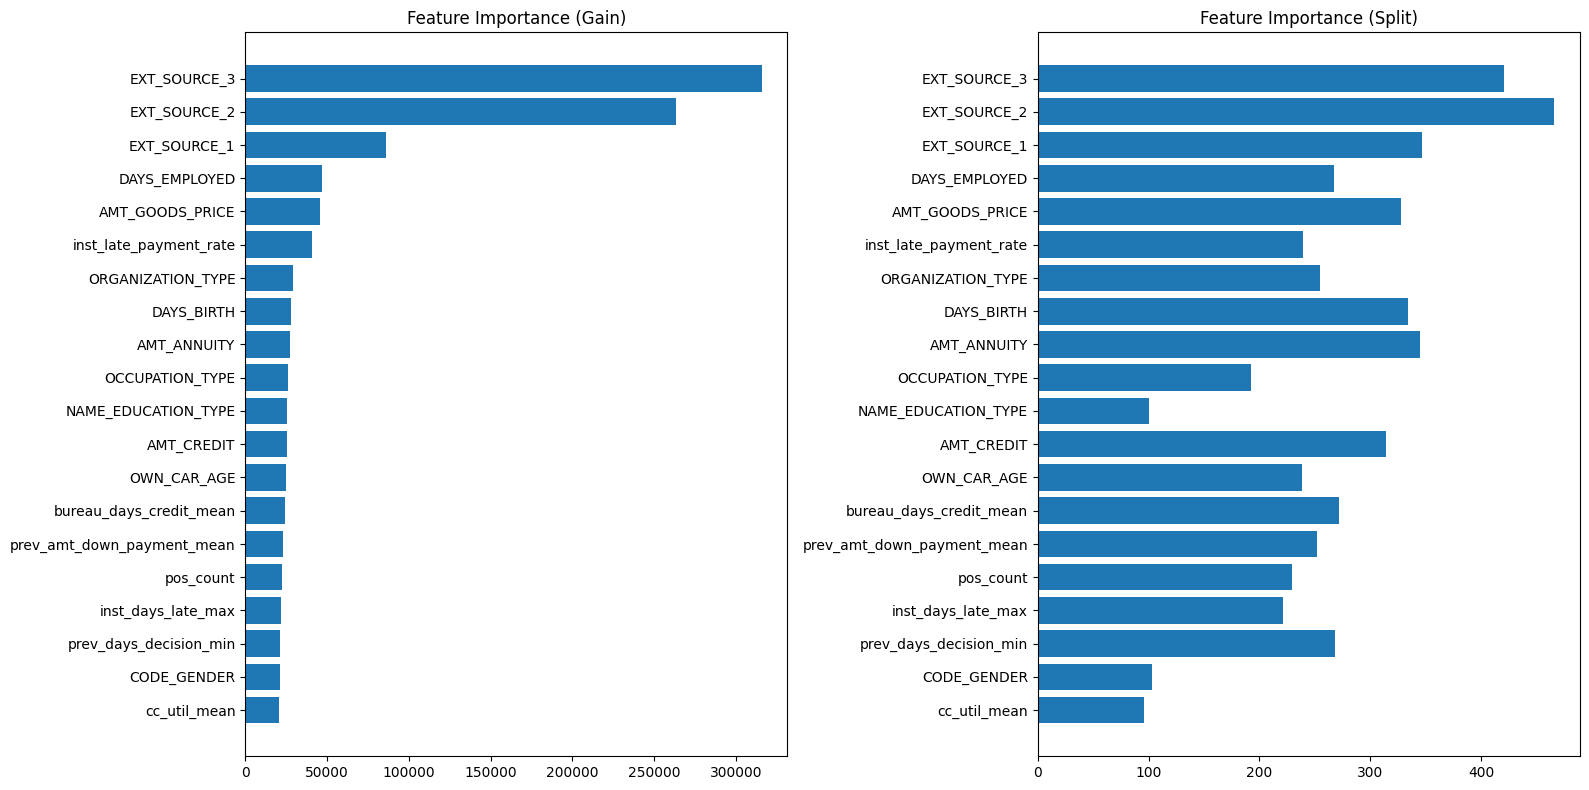

In [6]:
importance_df = pd.DataFrame({
    'feature'   : features,
    'gain'      : lgbm.booster_.feature_importance(importance_type='gain'),
    'split'     : lgbm.booster_.feature_importance(importance_type='split'),
}).sort_values('gain', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, col, title in zip(axes,
    ['gain', 'split'],
    ['Feature Importance (Gain)', 'Feature Importance (Split)']):
    top = importance_df.head(20)
    ax.barh(top['feature'], top[col])
    ax.set_title(title)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

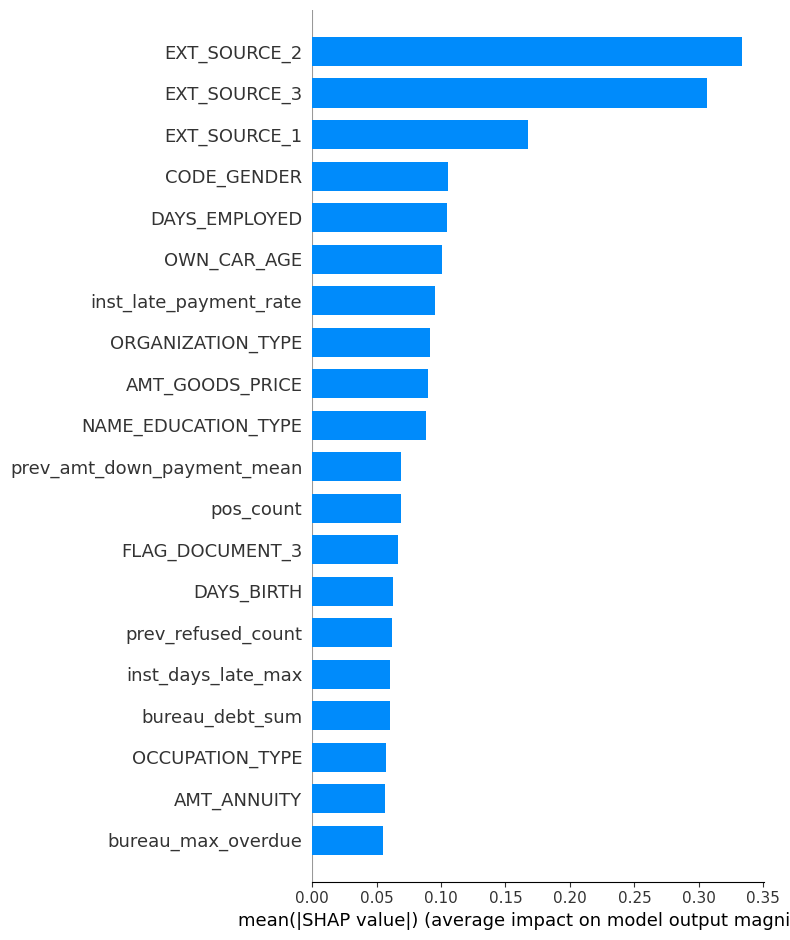

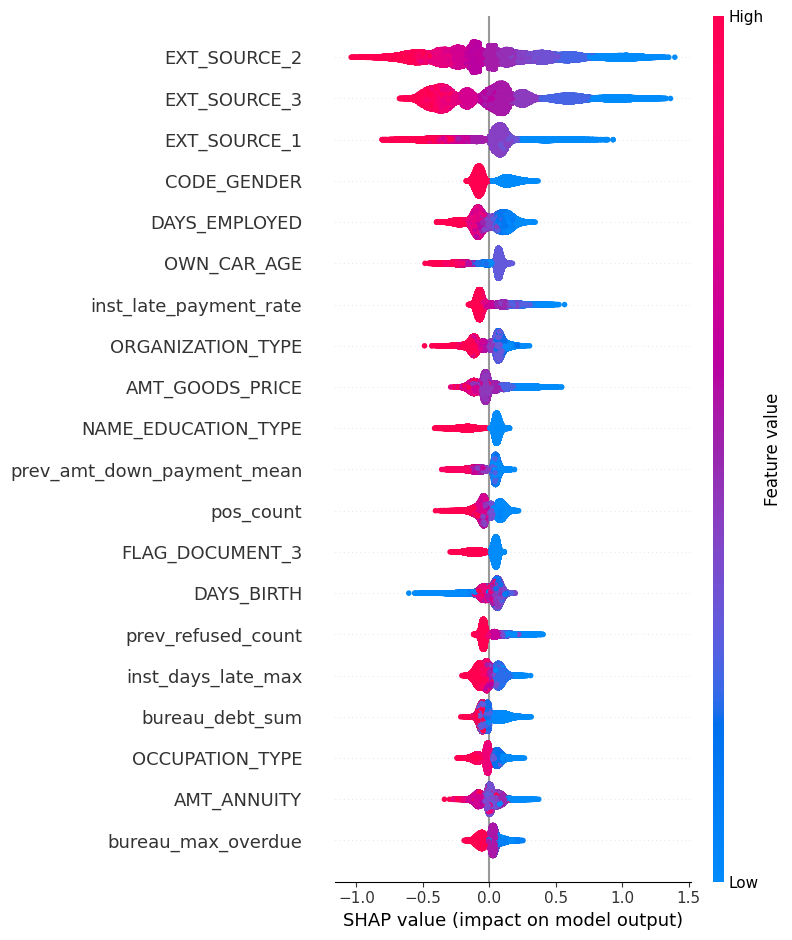

In [7]:
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_train)

# Summary plot — общий обзор важности и направления влияния
shap.summary_plot(
    shap_values,
    X_train,
    plot_type='bar',
    max_display=20,
    show=True
)

# Dot plot — детальное влияние каждого признака
shap.summary_plot(
    shap_values,
    X_train,
    max_display=20,
    show=True
)

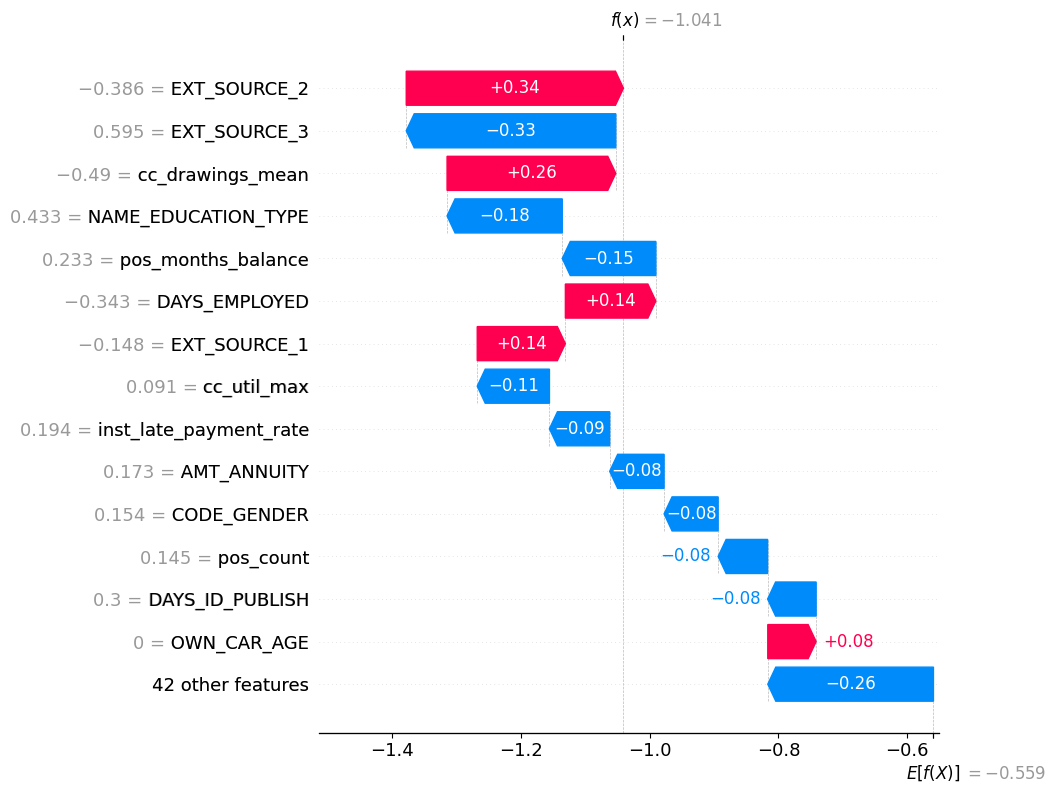

In [8]:
# Объяснение предсказания для одного клиента — показывает как каждый
# признак толкает скор вверх или вниз относительно базового значения

sample_idx = 0  # первый клиент из train

shap_explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_train.iloc[sample_idx],
    feature_names=features
)

shap.waterfall_plot(shap_explanation, max_display=15, show=True)

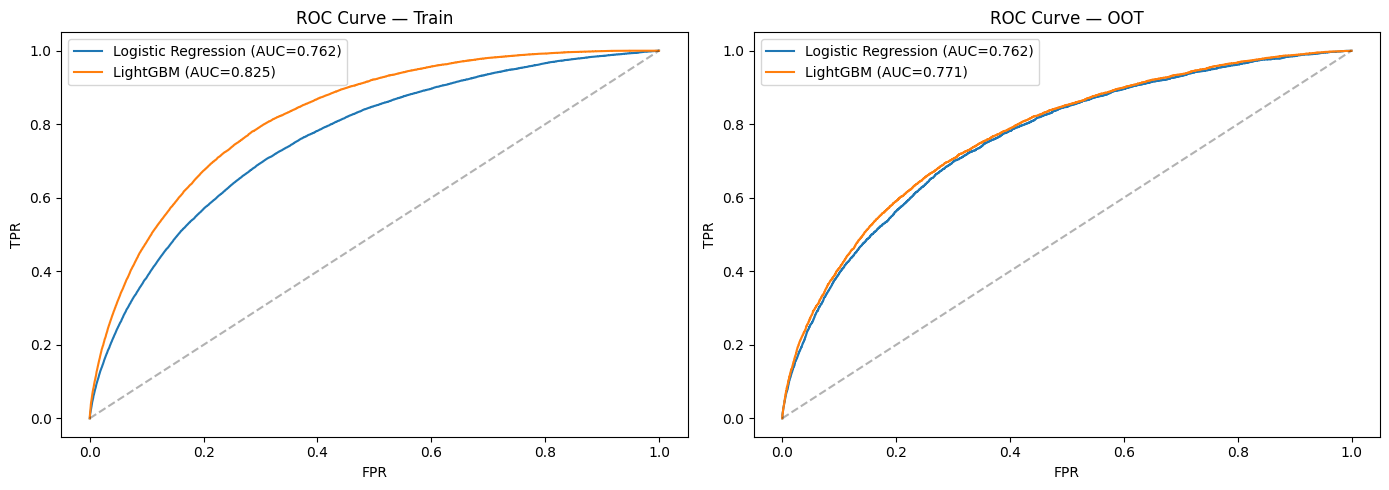

In [9]:
# Загружаем LR для сравнения
lr = joblib.load('../models/logreg_woe.pkl')
p_lr_train = lr.predict_proba(X_train)[:, 1]
p_lr_oot   = lr.predict_proba(X_oot)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (y, p_lr, p_lgbm, label) in zip(axes, [
    (y_train, p_lr_train, p_train, 'Train'),
    (y_oot,   p_lr_oot,   p_oot,   'OOT'),
]):
    for probs, name in [(p_lr, 'Logistic Regression'), (p_lgbm, 'LightGBM')]:
        fpr, tpr, _ = roc_curve(y, probs)
        auc = roc_auc_score(y, probs)
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(f'ROC Curve — {label}')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
joblib.dump(lgbm, '../models/lgbm_model.pkl')
print("Saved: models/lgbm_model.pkl")

# Сохраняем SHAP values для использования в финальном summary
np.save('../models/shap_values_train.npy', shap_values)
print("Saved: models/shap_values_train.npy")

Saved: models/lgbm_model.pkl
Saved: models/shap_values_train.npy


: 

## LightGBM Model Summary

### Model Performance vs Baseline

| Model | AUC Train | AUC OOT | KS Train | KS OOT | Gini OOT |
|---|---|---|---|---|---|
| DummyClassifier | ~0.50 | ~0.50 | ~0.00 | ~0.00 | ~0.00 |
| Logistic Regression | [вставь] | [вставь] | [вставь] | [вставь] | [вставь] |
| LightGBM | [вставь] | [вставь] | [вставь] | [вставь] | [вставь] |

### Key Findings
- LightGBM improves AUC by [вставь] points over Logistic Regression on OOT
- Top SHAP features align with EDA and IV results: EXT_SOURCE dominate
- SHAP dot plot confirms monotonic WoE relationships are preserved
- Train→OOT AUC degradation = [вставь] — indicates [no overfitting / mild overfitting]

### Model Choice for Scorecard
Logistic Regression is selected for the scorecard (notebook 07) due to:
- Full interpretability — each feature has a single coefficient
- Regulatory compliance — explainable to auditors and regulators
- Competitive AUC within acceptable range for retail credit scoring
LightGBM serves as performance benchmark.

**Next step:** Scorecard → notebook 07